In [8]:
import numpy as np
from PIL import Image
import random


def voronoi_brute(sites, width = 400, height = 400):
    sites = np.array(sites)
    colors = [(random.randint(80,255),
               random.randint(80,255),
               random.randint(80,255)) for _ in sites]

    ys, xs = np.mgrid[0:height, 0:width]
    px = np.stack([xs, ys], axis = -1)

    dists = np.linalg.norm(
        px[:, : , None, :] - sites[None, None, :, :],
        axis = -1
    )
    nearest = np.argmin(dists, axis = -1)

    color_map = np.array(colors)
    img_array = color_map[nearest]
    img = Image.fromarray(img_array.astype(np.uint8))

    from PIL import ImageDraw
    draw = ImageDraw.Draw(img)

    for x, y in sites:
        draw.ellipse([x-4, y-4, x + 4, y + 4], fill = (0,0,0))
    return img


sites = [(random.randint(20,380), random.randint(20,380))
        for _ in range(12)]

img = voronoi_brute(sites)
img.save('voronoi.png')
img.show()

[[ 3.17598152  3.07263279]
 [ 2.12368421 -0.19210526]
 [ 3.46891892  2.69054054]
 [ 0.59766355  1.71542056]
 [ 3.1525      3.078     ]]
[[3 1]
 [3 0]
 [3 5]
 [5 4]
 [5 1]
 [2 1]
 [2 0]
 [2 4]
 [1 4]
 [1 0]]
[[1, 2], [-1, 1], [-1, 2], [-1, 0], [0, 2], [3, 4], [-1, 3], [-1, 4], [0, 4], [1, 3]]
[[-1, 2, 1], [-1, 0, 2], [-1, 4, 3], [4, 0, 2, 1, 3], [-1, 1, 3], [-1, 0, 4], []]
[4 3 2 0 5 1]
nearest: [0 5] dists: [0.86  1.656]
sitio 0: area = None
sitio 1: area = 4.196744155331606
sitio 2: area = None
sitio 3: area = None
sitio 4: area = None
sitio 5: area = None


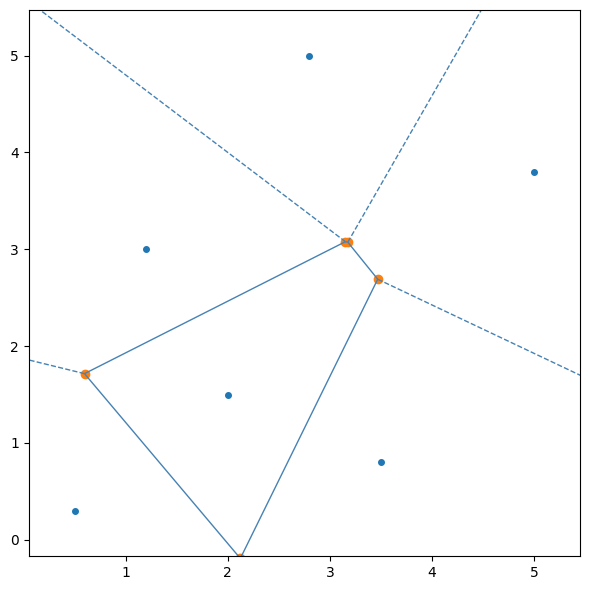

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import Voronoi, voronoi_plot_2d


points = np.array([
    [0.5, 0.3], [2.0,1.5],[1.2,3.0],
    [3.5,0.8], [2.8, 5.0], [5.0,3.8],
])

vor = Voronoi(points)

print(vor.vertices)
print(vor.ridge_points)
print(vor.ridge_vertices)
print(vor.regions)
print(vor.point_region)


fig, ax = plt.subplots(figsize = (6,6))
voronoi_plot_2d(vor, ax=ax, show_vertives=True,
                line_colors = 'steelblue', point_size=8)
plt.tight_layout()
plt.savefig('voronoi_scipy.png', dpi=150)



from scipy.spatial import KDTree
tree = KDTree(points)
query = np.array([[1.0,1.0], [3.55,3.0]])
dists, idx = tree.query(query)

print("nearest:" , idx, "dists:", dists.round(3))


from scipy.spatial import ConvexHull

def region_area(vor, point_idx, bbox = (0,5,0,5)):
    region = vor.regions[vor.point_region[point_idx]]
    if -1 in region or not region:
        return None
    verts = vor.vertices[region]

    return ConvexHull(verts).volume

for i in range(len(points)):
    area = region_area(vor, i)
    print(f"sitio {i}: area = {area}")



In [11]:
import heapq
from dataclasses import dataclass, field
from typing import Optional


@dataclass

class Site:
    x: float; y: float
    idx: int = 0

@dataclass(order=True)
class Event:
    y: float
    kind: str = field(compare=False)
    site: Optional[Site] = field(default=None, compare =False)
    arc: Optional[object] = field(default=None, compare =False)
    valid: bool = field(default=True, compare = False)


def parabola_x(site, sweep_y, query_y):
    d = site.y - sweep_y
    if abs(d) < 1e-10: return site.x
    return (query_y**2 - 2*site.y*query_y + site.x**2
            + site.y**2 - sweep_y**2) / (2 * d)



def circle_event(a,b,c):
    ax, ay = a.x - b.x, a.y - b.y
    cx, cy = c.x - b.x, c.y - b.y
    d = 2 * (ax*cy - ay * cx)
    if abs(d) < 1e-10: return None
    ux = (cy*(ax**2+ay**2) - ay*(cx**2+cy**2)) / d
    uy = (ax*(cx**2+cy**2) - cx*(ax**2+ay**2)) / d
    cx_abs = b.x + ux
    cy_abs = b.y + uy
    r = (ux**2 + uy**2)**0.5
    return cx_abs, cy_abs, r


def fortune(sites):
    events = []
    for i, (x,y) in enumerate(sites):
        heapq.heappush(events,
                       Event(y=-y, kind='site',
                               site = Site(x,y,i)))

    vertices, edges = [], []
    beach_line = []


    while events:
        ev = heapq.heappop(events)
        if not ev.valid: continue

        if ev.kind == 'site':
            handle_site_event(ev.site, beach_line,
                              events, edges)
        else:
            handle_circle_event(ev.arc, beach_line,
                                events, vertices, edges)

    return vertices, edges


Triangulos:  (22, 3)


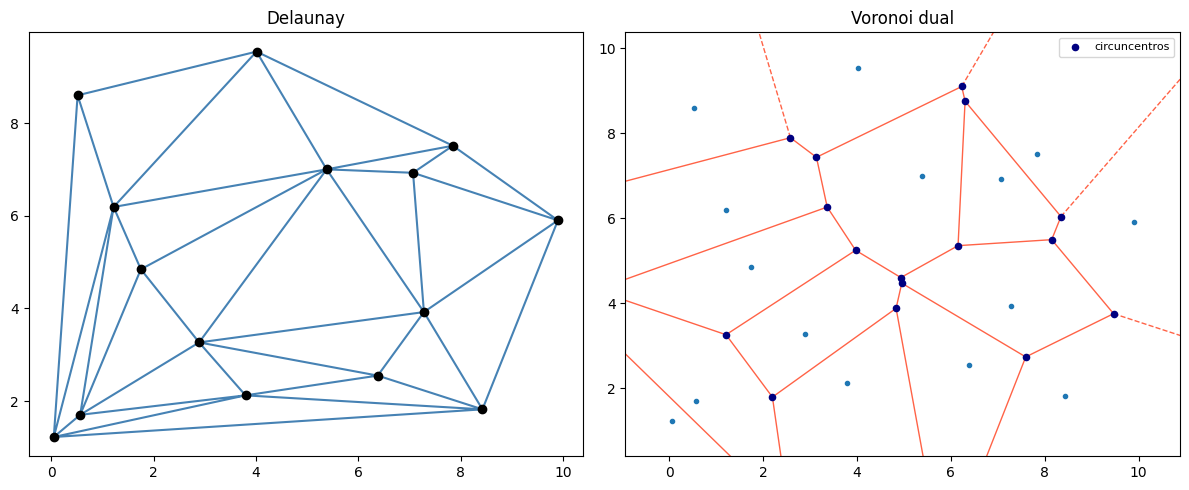

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import Delaunay, Voronoi

points = np.random.rand(15,2) * 10

tri = Delaunay(points)
print("Triangulos: ", tri.simplices.shape)

def circumcenter(A,B,C):
    ax, ay = B - A
    bx, by = C - A
    D = 2 * (ax * by - ay*bx)
    if abs(D) < 1e-10: return None
    ux = (by*(ax**2+ay**2) - ay*(bx**2+by**2)) / D
    uy = (ax*(bx**2+by**2) - bx*(ax**2+ay**2)) / D

    return A + np.array([ux, uy])


cc = []
for simplex in tri.simplices:
    A,B,C = points[simplex]
    c = circumcenter(A,B,C)
    if c is not None: cc.append(c)
cc = np.array(cc)


fig, axes = plt.subplots(1,2, figsize = (12,5))

axes[0].triplot(points[:,0], points[:,1],
                tri.simplices, color ='steelblue')
axes[0].scatter(*points.T, c='black', zorder=3)
axes[0].set_title('Delaunay')


from scipy.spatial import voronoi_plot_2d
vor = Voronoi(points)
voronoi_plot_2d(vor, ax=axes[1],
                show_vertices=False,
                line_colors='tomato', point_size=6)

axes[1].scatter(*cc.T, c='navy', s=20,
                label='circuncentros', zorder=3)
axes[1].legend(fontsize=8)
axes[1].set_title('Voronoi dual')

plt.tight_layout()
plt.savefig("delaunay_voronoi.png", dpi=150)


In [16]:
import numpy as np
import heapq

def nn_brute(points, query, k=1, metric='euclidean'):
    if metric == 'euclidean':
        dists = np.linalg.norm(points - query, axis = 1)
    elif metric == 'manhattan':
        dists = np.sum(np.abs(points - query), axis = 1)
    elif metric == 'cosine':
        norms = np.linalg.norm(points, axis = 1) * np.linalg.norm(query)
        dists = 1 - (points @ query) / np.maximum(norms, 1e-10)

    idx = np.argpartition(dists, k)[:k]
    idx = idx[np.argsort(dists[idx])]
    return idx, dists[idx]


def knn_pure(points, query, k = 3):
    heap = []
    for i, p in enumerate(points):
        d = sum((a-b)**2 for a, b in zip(p, query)) ** 0.5
        if len(heap) < k:
            heapq.heappush(heap, (-d,i))
        elif d < -heap[0][0]:
            heapq.heapreplace(heap, (-d, i))
    return sorted((i, -d) for d, i in heap)


np.random.seed(42)
points = np.random.rand(1000,3)
query = np.array([0.5, 0.5, 0.5])
idx, dists = nn_brute(points, query, k = 5)
print("5-NN:", idx, dists.round(4))


5-NN: [ 77 287 379 625 896] [0.0773 0.0793 0.0945 0.1001 0.1008]


In [18]:
from collections import namedtuple
import heapq

KDNode = namedtuple('KDNode', ['point','idx','left','right','axis'])

def build_kdtree(points, depth= 0):
    if not points: return None
    k = len(points[0][0])
    axis = depth % k
    points.sort(key=lambda x: x[0][axis])
    mid = len(points) // 2
    return KDNode(
        point = points[mid][0],
        idx=points[mid][1],
        left=build_kdtree(points[:mid], depth+1),
        right=build_kdtree(points[mid+1:], depth+1),
        axis = axis
    )


def knn_kdtree(node, query, k, heap=None):
    if heap is None: heap = []
    if node is None: return

    d = sum((a-b)**2 for a, b in zip(node.point, query)) ** 0.5
    if len(heap) < k:
        heapq.heappush(heap, (-d, node.idx))
    elif d < -heap[0][0]:
        heapq.heapreplace(heap, (-d, node.idx))

    axis = node.axis
    diff = query[axis] - node.point[axis]
    near, far = (node.left, node.right) if diff <= 0 \
                else (node.right, node.left)

    knn_kdtree(near, query, k, heap)
    if len(heap) < k or abs(diff) < -heap[0][0]:
        knn_kdtree(far, query, k, heap)

    return heap



from scipy.spatial import KDTree
import numpy as np

point = np.random.rand(10000, 3)
tree = KDTree(points)

query = np.array([0.5,0.5,0.5])

dist, idx = tree.query(query)
dists, idx = tree.query(query, k = 5)

idxs_r = tree.query_ball_point(query, r=0.1)

queries = np.random.rand(100,3)
dists, idxs = tree.query(queries, k = 3)

pairs, idxs = tree.query(queries, k = 3)

pairs = tree.query_pairs(r=0.05)
